# AAI6640 2026 Spring Assignment 1

# Section One

## <div class="alert alert-info">[GRADED  TASK 1.1]</div>
Please explain the reason gradient descent minimizes training loss

### Your answer
The reason gradient descent minimizes training loss is that its constantly updating the model's parameters. These continuous, iteratively parameters updates happen in the opposite direction of the the steepest part within the loss. The goal is to move on a direction toward lower loss values. For instance, a hiker has reached the peak of Mt Everest and the increase loss in this case would be lack Oxygen and warmth of the sun. To resolve this, hikers must track back down to the bottom of the mountain for better air quality and the opportunity to warm back up. The gradient of the mountain helps tell us which was is up or down, and in this case whether loss is increased or decreased.

Utilizing the Taylor series approximation, a technique similar to heuristic search algorithms, where the idea of getting from start to goal is finding the least costly path of edges and nodes to the goal. From a Taylor series persepective we are utilizing the negative gradient direction to find the cost that was less than the previous, while monitoring the learning rate and ensuring it remains small.


## <div class="alert alert-info">[GRADED  TASK 1.2]</div>
Please explain the steps of __backpropagation__ algorithm. The final result should include the updating rules for all the weights and biases for output layer and hidden layers.

Architecture of the fully connected neural network:
- d inputs
- 1 output
- L hidden layers with n neurons per layer
- activation function: sigmoid function
- loss function: cross-entropy

### Your answer
The core idea of backpropagation algorithm is working from goal to start by evaluating the weights that contributed to the mistakes. In doing so we implement  the chain rule, which calculate show much each weight contributed to the errors. Backpropagation requires the derivative of the active function because it allows us to exactly how much each weight errors that were identified actually contributed to the error. The derivative works as an error beacon and when one is found it helps determine if the algorithm is sensitive or saturated. Meaning if the derivative is high (sensitive), any small changes to the weights ultimately affect the overall output. But, when the derivative is low (saturated), there will be little to no impact on the output. This is key because it allows us to understand the gradient of the algorithm and use it as a guide in contrast with the Chain rule to:
Get the exact amount of each weight error contributions
Using chain rule to precisely calculate the gradient for all weights in the algorithm no matter the depth


Sigmoid Function: Sigmoid is used for binary output and takes any number and squashes it to a range between 0 and 1,  where its output representsa probability. By utilizing its derivative, “a(1-a)”, we can measure how sensitive or saturated the inputs are based off input changes. The higher the derivative the more sensitive; the lower the derivative the more saturated. For instance, if we had 0.5 > derivative = 0.5(1 - 0.5) or 0.5 x 0.5 = 0.25 (mostly sensitive); or a more saturated instance, 0.99 > derivative = 0.99 (1 - 0.99) = or 0.99 x 0.01 = 0.0099

Cross-Entropy Loss: Cross-entropy is the used for classification tasks within backpropgation, to classify the loss. It informs us whether the prediction is wrong,how was it wrong, then contrast it and penalize confident wrong predictions.

Why they work well together: Furthermore, cross-entropy loss and sigmoid activation work well together because it allows for errors to be scored in between 0 and 1, making adjusts in manageable increments but the overall computation extremely fast. With small adjustable increments it also allowed for gradients to be stable and not inconsistent with random numerical values. On the mathematical side, the combination of the two allows for a simplified math equation to calculate the error term; δ = prediction - actual or (a - y).


The Backpropagation Algorthim steps:

Step 1 - Initialization: Before the training begins we need to initialize all the weights (W) and biases (b), by assigning small random values at every layer. This is beneficial for during training because it allowed the neurons to learn different features while all starting at a different points.

Step 2 - Forward Pass: In forward pass data trickles through the network from input,going layer by layer, until it reaches output and converges. At each layer, its achieves two things, the calculation of the weighted sum (z) and the activation(a). The weighted sum is calculated by multiplying weights and neurons and adding the bias; represented as z = W * a + b. At the base or 1st layer we use the initial input(x), so the formula is z = W * x + b (at layer 1).

For all over layers, we use the previous layer’s activation output (a) which is formulated as z(ℓ) = W(ℓ) * a(ℓ-1) + b(ℓ) (at layer 2). The “a” for activation takes in the weighted sum (z) and utilized sigmoid activation to squash its output between 0 and 1. Allows for a more accurate representation of the layers weight (a = σ(z)). This step is repeated at all layers until we get a final output which is our prediction.

Step 3 - Calculating loss:
After the forward pass,we have the prediction(ŷ) and the actual label(y) .Using cross-entropy loss formula we can compare the:J=−[y⋅log(y^​)+(1−y)⋅log(1−y^​)].J represents the loss, how wrong the answer was. For instance, a prediction of 0.95 and loss of 0.05 shows we had a low loss and almost correct. But if the actualis 1 and a prediction of 0.05, the loss is 3.00, shows we have a high loss and confidently wrong. As a result, the confident wrong answers are harshly punishes those values.

Step 4 - Backward Pass:
The backward pass is one the most important steps in all of the backpropagation structure. The process involves calculating the contribution of each layer to the overall error by navigating backwards through the network, layer by layer. We start with the final goal and work our way reverse to determine the error term at each layer(δ).

Navigating through the output layer can be done by subtracting the prediction from the actual:​​δ⁽ᴸ⁺¹⁾ = a⁽ᴸ⁺¹⁾ − y. But for the more complex hidden layers, it requires finding the errors at the next layer and passing it back through the weights and then multiplied by the sigmoid derivative: ⁽ℓ⁾ = (W⁽ℓ⁺¹⁾)ᵀ · δ⁽ℓ⁺¹⁾ ⊙ a⁽ℓ⁾(1 − a⁽ℓ⁾). The sigmoid derivative is then indicates of how sensitive the layer actually was. So if a layer was saturated with a low derivative, you can confirm it barely contributed and the error term would be small. As for a higher derivative, confirms it contributed a larger error term.

Step 5 - Update Parameters:
Now that we have the error terms calculated for each layer, we can calculate the gradients to update all weights and biases. In order to get the gradient for each weight, multiply the error term by the input weight. And for the bias, its simply the error term: ∂J/∂b⁽ℓ⁾ = δ⁽ℓ⁾. The final update comes by using the gradient descent, where n represents the learning rate and applied to all layers. The learning rate is a hyperparameter set that controls how the weights are updated, ensuring there is a well enough balance to not under or over shoot.

Step 6 - Repeat:

While step 6 is nothing short of a rinse and repeat process until convergence or a specific set of iterations is reached; this is represented a an epoch.

# Section Two - Coding Perceptron

## <div class="alert alert-info">[GRADED  TASK 2.1]</div>

Please realize the __perceptron__ algorithm from scratch with Numpy.

In [19]:
# imports
import numpy as np

# Perceptron class
class Perceptron:

  # initialize, store hyperparameters and interations
  def __init__(self, learning_rate=0.01, n_interations=1000):
    self.lr = learning_rate
    self.n_inters = n_interations
    self.weights = None
    self.bias = None


  def activation(self, z):
    # z represents the weighted sum
    # 1 and zero are the outputs from the activation
    # if greater than or equal 0 return 1, if not return 0
    return np.where(z >= 0, 1, 0)

  # Forward Pass
  def fit(self, X, y):
    # get number of samples from the shape
    n_samples, n_features = X.shape
    #print(n_samples)
    #print(n_features)

    # intialize weights and biases,
    '''
    - using n_zeros instead of small random values for this simple version of perceptron;
    - need 2 weights to connect to one feature.
    - It will be useful for OR Gates
    '''
    self.weights = np.zeros(n_features)
    self.bias = 0


    # Training loop
    for _ in range(self.n_inters):
      # this will loop for every layer until convergence
      for x_index, x_sample in enumerate(X):
        # calculated the weighted sum
        z = np.dot(x_sample, self.weights) + self.bias

        # get the prediciton, using the weighted sum
        y_pred = self.activation(z)

        # utilizing cross-entropy loss and sigmoid to calculate the error term
        # calculate the update
        update = self.lr * (y[x_index] - y_pred)

        # update weights and bias
        self.weights += update * x_sample
        self.bias += update

  def predict(self, X):
    # calculate weighted sum
    z = np.dot(X, self.weights) + self.bias

    # get the prediciton, using the weighted sum
    return self.activation(z)








# Define OR gate data
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 1])
model = Perceptron()
model.fit(X, y)

print(model.predict(X))

[0 1 1 1]


## <div class="alert alert-info">[GRADED  TASK 2.2]</div>

Please use the homemade __perceptron__ algorithm to simulate an __OR__ gate

In [20]:
'''
Using the perceptron data to simulate an OR gate.
The OR Gate is used to print the learned weights, biases and predictions.
Its the simpliest way the layers in the model can "learn".

The OR gate is linearly seperable, if you were have a visual, you would be able to draw
a decision boundary that clearly shows the split between 0s and 1s

'''


# input data
X_or = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# OR Gate Labels
y_or = np.array([0, 1, 1 ,1])

perceptron_or = Perceptron()
perceptron_or.fit(X_or, y_or)
predictions = perceptron_or.predict(X_or)


# print results
print("----- OR Gate Results -----")
print("-" * 45)
for i in range(len(X_or)):
  print(f'Input: {X_or[i]} | Expected: {y_or[i]} | Predicted: {predictions[i]}')
print("-" * 20)
accuracy = np.mean(predictions == y_or)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("-" * 45)



# display Weights, biases, predictions,
print(f'Weights: {perceptron_or.weights}')
print(f'Bias: {perceptron_or.bias}')
print(f'Predictions: {perceptron_or.predict(X_or)}')






----- OR Gate Results -----
---------------------------------------------
Input: [0 0] | Expected: 0 | Predicted: 0
Input: [0 1] | Expected: 1 | Predicted: 1
Input: [1 0] | Expected: 1 | Predicted: 1
Input: [1 1] | Expected: 1 | Predicted: 1
--------------------
Accuracy: 100.00%
---------------------------------------------
Weights: [0.01 0.01]
Bias: -0.01
Predictions: [0 1 1 1]


## Data for 2.3 ~ 2.5

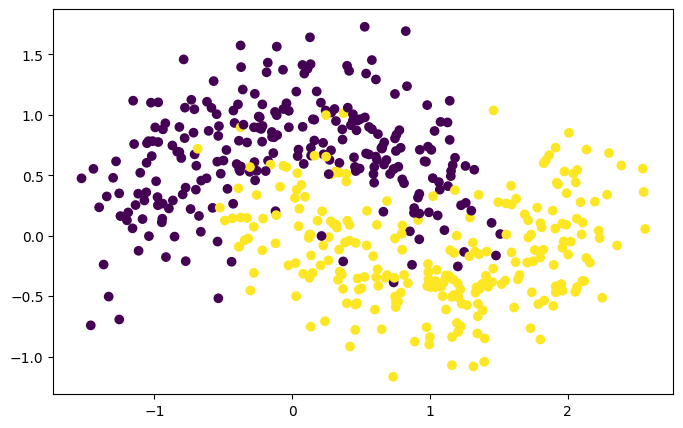

In [21]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

X, y = make_moons(n_samples=500, noise=0.3, random_state=2026)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)

## <div class="alert alert-info">[GRADED  TASK 2.3]</div>

Please test the homemade __perceptron__ algorithm in section 2.1
- No need to split the data into train and test.
- Report and visualize the classification results.

Homemade Perceptron Accuracy: 58.40%



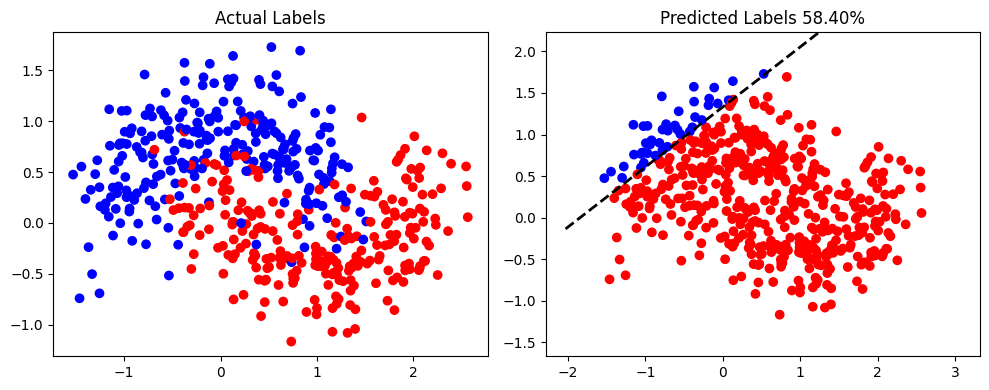

----- Perceptron Results -----
Weights: [ 0.05426306 -0.07506946]
Bias: 0.1

---------------------------------------------

The homemade Perceptron model achieve an accuracy score of 58.4% againt the
make_moon dataset. The accuracy is fairly low because the dataset is 
non-linearly seperable, unlike the smaller numpy arrary. With perceptron only 
able to learn on linear decision boundaries, this type dataset struggles 
with identifying a single straight boundary line. Although the predicted labels show 
 a rough linear decision boundary, the perception is not accurate
enough to represent classify all the datapoints.


I added on the decision boundary demonstrated on the Predicted labels. The models speed, seems fairly slow with and
average execution rate around 6-7 secs. something to be mindful of.




In [22]:
# Instantiate the model
perceptron = Perceptron(learning_rate=0.1, n_interations=1000)

# train the model
perceptron.fit(X, y)

# make predictions
predictions = perceptron.predict(X)

# Calculate the models accuracy
accuracy = np.mean(predictions == y)
print(f'Homemade Perceptron Accuracy: {accuracy * 100:.2f}%\n')

# ----- Visualize Model Results ------

# figure size
plt.figure(figsize=(10, 4))

# Plot Actual v Predicted Labels
# ------ Plot 1 ----------
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title('Actual Labels')

# ------ Plot 2 ----------
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='bwr')


# Draw a decision boundary line where w1*x1 + w2*x2 + bias = 0
x1_line = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
x2_line = -(perceptron.weights[0] * x1_line + perceptron.bias) / perceptron.weights[1]
plt.plot(x1_line, x2_line, 'k--', linewidth=2, label='Decision Boundary')
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5) # keep y-axis in range



plt.title(f'Predicted Labels {accuracy * 100:.2f}%')
plt.tight_layout()
plt.show()


# ---- Summary of the results ------
print("----- Perceptron Results -----")
# display Weights, biases, predictions,
print(f'Weights: {perceptron.weights}')
print(f'Bias: {perceptron.bias}\n')
print("-" * 45)


results_summary = '''
The homemade Perceptron model achieve an accuracy score of 58.4% againt the
make_moon dataset. The accuracy is fairly low because the dataset is
non-linearly seperable, unlike the smaller numpy arrary. With perceptron only
able to learn on linear decision boundaries, this type dataset struggles
with identifying a single straight boundary line. Although the predicted labels show
 a rough linear decision boundary, the perception is not accurate
enough to represent classify all the datapoints.


I added on the decision boundary demonstrated on the Predicted labels. The models speed, seems fairly slow with and
average execution rate around 6-7 secs. something to be mindful of.

'''

print(results_summary)


## <div class="alert alert-info">[GRADED  TASK 2.4]</div>

Please test __perceptron__ algorithm from sklearn
- No need to split the data into train and test.
- Report and visualize the classification results.
- random_state=2026, all other parameters use default
- Compare to the results in Section 2.3

Sklearn Perceptron Accuracy: 83.00%



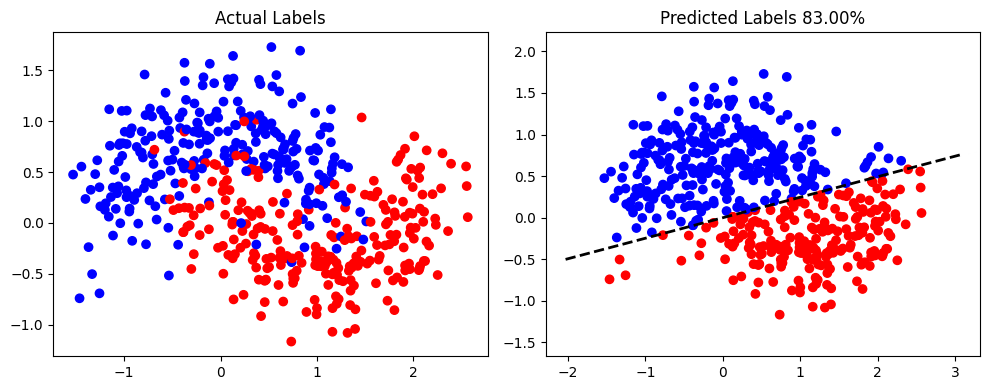

----- Sklearn Results -----
Weights: [ 0.08285752 -0.33557045]
Bias: 0.0

---------------------------------------------

The sklearn Perceptron model achieved an accuracy of 83% compared to the homemade
Perceptron model on the make_moon data with a score of 58.4%. The sklearn library handles alot of 
the heavy work, that the homemade model had to create using a Perceptron class.
What i did find is that although sklearn accuracy is higher, both the homemade and sklearn models
still limited in linear seperability. From the predicted to the actual you can see the 
actual has a crescent shape, that doesn't allow for a linear decision boundary.
The sklearn model displayed a bias of 0.0, emphasizing that the decision boundary only passes
through the origin area, while the homemade perceptron learned a different boundary located in the top left hand
corner. Sklearn performance emphasize that it is more optimized (w/ better learning rates,
weight initializations, predictions, bias). Due to the

In [23]:
# Your answer here
from sklearn.linear_model import Perceptron

#Making a perceptron classifier
sklearn_perceptron = Perceptron(max_iter=100, eta0=0.1, random_state=2026)
sklearn_perceptron.fit(X, y)

# get predictions
predictions_sklearn = sklearn_perceptron.predict(X)


# Calculate the models accuracy
accuracy = np.mean(predictions_sklearn == y)
print(f'Sklearn Perceptron Accuracy: {accuracy * 100:.2f}%\n')

# ----- Visualize Model Results ------

# figure size
plt.figure(figsize=(10, 4))

# Plot Actual v Predicted Labels
# ------ Plot 1 ----------
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title('Actual Labels')

# ------ Plot 2 ----------
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=predictions_sklearn, cmap='bwr')


# Draw a decision boundary line where w1*x1 + w2*x2 + bias = 0
x1_line = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
x2_line = -(sklearn_perceptron.coef_[0][0] * x1_line + sklearn_perceptron.intercept_[0]) / sklearn_perceptron.coef_[0][1]
plt.plot(x1_line, x2_line, 'k--', linewidth=2, label='Decision Boundary')
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5) # keep y-axis in range



plt.title(f'Predicted Labels {accuracy * 100:.2f}%')
plt.tight_layout()
plt.show()


# ---- Summary of the results ------
print("----- Sklearn Results -----")
# display Weights, biases, predictions,
print(f'Weights: {sklearn_perceptron.coef_[0]}')
print(f'Bias: {sklearn_perceptron.intercept_[0]}\n')
print("-" * 45)


results_summary = '''
The sklearn Perceptron model achieved an accuracy of 83% compared to the homemade
Perceptron model on the make_moon data with a score of 58.4%. The sklearn library handles alot of
the heavy work, that the homemade model had to create using a Perceptron class.
What i did find is that although sklearn accuracy is higher, both the homemade and sklearn models
still limited in linear seperability. From the predicted to the actual you can see the
actual has a crescent shape, that doesn't allow for a linear decision boundary.
The sklearn model displayed a bias of 0.0, emphasizing that the decision boundary only passes
through the origin area, while the homemade perceptron learned a different boundary located in the top left hand
corner. Sklearn performance emphasize that it is more optimized (w/ better learning rates,
weight initializations, predictions, bias). Due to the make_moons dataset being non-linearly seperable
both models struggle to fully solve the make_moons problem. As a result, the crescent shape suggests
a curved decision boundary that is not linear is required. This may also require a multi-layer network
'''

print(results_summary)


## <div class="alert alert-info">[GRADED  TASK 2.5]</div>

Please test __MLP__ algorithm from sklearn
- No need to split the data into train and test.
- Report and visualize the classification results.
- random_state=2026, all other parameters use default
- Compare to the results in Section 2.4

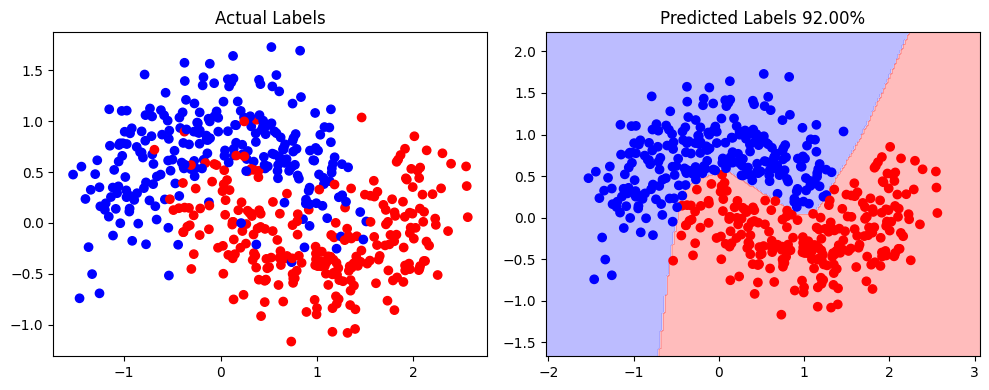

MLP Accuracy: 92.00%

MLP hidden layers size (100,)
Number of Layers 3
Number of Outputs 1
Activation Function relu
---------------------------------------------


The MLP Classifier model achieved an accuracy of 92% , which outperformed the sklearn
and homemade models. I did find that for the default parameters, when I did not include
max_inters=1000, the model default performance lowered the accuracy to 89.6%. Not a significant difference
but does show the main default compared to a set default will show slightly different results.
It also confirmed that it needed more iterations to fully converge, requiring more training time
for better model optimization

Final Results from all 3 models
- Homemade Perceptron Accuracy: 58.40%
  - 2 weights + 1 bias (simplest)
- Sklearn Perceptron Accuracy: 83.33%
  - 2 weights + 1 bias (most optimized)
- MLP Accuracy: 92.00% (89.60% w/o max_inters set to 1000)
  - 100 neurons x multiple weight connections (most complex)
  - 100 hidden layers size
  

In [29]:
# Your answer here
from sklearn.neural_network import MLPClassifier

# instantiate, create, train, fit MLP
mlp = MLPClassifier(random_state=2026, max_iter=1000)
mlp.fit(X, y)

# get predictinos
mlp_predictions = mlp.predict(X)

# Calculate the models accuracy
accuracy = np.mean(mlp_predictions == y)


# ----- Visualize Model Results ------


# create curve decision boundaries using a mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
  )

# predict the mesh grid
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# figure size  and plot
plt.figure(figsize=(10, 4))

# Plot Actual v Predicted Labels
# ------ Plot 1 ----------
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title('Actual Labels')

# ------ Plot 2 ----------
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=mlp_predictions, cmap='bwr')
plt.title(f'Predicted Labels {accuracy * 100:.2f}%')


plt.tight_layout()
plt.show()


# ---- Summary of the results ------

# MLP Strucuture
print(f'MLP Accuracy: {accuracy * 100:.2f}%\n')
print(f'MLP hidden layers size {mlp.hidden_layer_sizes}')
print(f'Number of Layers {mlp.n_layers_}')
print(f'Number of Outputs {mlp.n_outputs_}')
print(f'Activation Function {mlp.activation}')


print("-" * 45)


results_summary = '''

The MLP Classifier model achieved an accuracy of 92% , which outperformed the sklearn
and homemade models. I did find that for the default parameters, when I did not include
max_inters=1000, the model default performance lowered the accuracy to 89.6%. Not a significant difference
but does show the main default compared to a set default will show slightly different results.
It also confirmed that it needed more iterations to fully converge, requiring more training time
for better model optimization

Final Results from all 3 models
- Homemade Perceptron Accuracy: 58.40%
  - 2 weights + 1 bias (simplest)
- Sklearn Perceptron Accuracy: 83.33%
  - 2 weights + 1 bias (most optimized)
- MLP Accuracy: 92.00% (89.60% w/o max_inters set to 1000)
  - 100 neurons x multiple weight connections (most complex)
  - 100 hidden layers size
  - Number of layers identified: 3 (input > hidden > output)
  - each neuron learned different features of the crescent shape

It also achieved the highest score because it include the hidden layers, using ReLU activation.
This allows the model to follow a non-linear decision boundary, and follow a more curve moon shape
type boundary by allowing the model to access multiple layers to create the complex boundary.

As a result MLP algorithm seems the most ideal model to use when working with non-linearly
seperable data like make_moons dataset. It allows movement in functionality through
a multi-layer network, unlike a single-layer perceptron that only can solve linearly seperable operations
(like and OR Gate in the above section).

Its noted that for more complex, multi-layer models prefer MLP and not perceptron.
ReLU activation  is applie after each layer to help learn the curves and non-linearity
of the shape of the data. This helps form the complex decision boundary as shown in the predict
labels visualization, with using the split color boundary. In combination together, it creates
the smooth curve


Some more key findings:
The MLP was not perfect, with a 8% error difference
due to some noisy data (make_moons noise=0.3) and overlapping points, where the two red and blue
classes could not be completely seperated.



'''

print(results_summary)
